# 09: PTQTP (Post-Training Quantization to Trit-Planes)

Convert a float model to ternary without training.

Simple absmean ($W_t = \text{round}(W / \text{mean}|W|)$) maps each weight to one ternary value.
PTQTP uses two ternary planes:

$$W \approx \alpha_1 T_1 + \alpha_2 T_2$$

where $T_1, T_2 \in \{-1, 0, +1\}$ and $\alpha_1, \alpha_2$ are per-row float scales.
T1 captures coarse structure, T2 corrects the residual. The zero state filters noise.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path("../")))

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## Algorithm

Minimize $\|W - \alpha_1 T_1 - \alpha_2 T_2\|^2$ over discrete $T \in \{-1,0,+1\}$ and continuous scales $\alpha$. Can't solve jointly, so alternate between the two:

**Solve scales (T fixed).** Per-row 2x2 solve linear system using Ridge-regularized Cramer's rule, since T1 and T2 can be correlated.

**Solve T (scales fixed).** Each element independent: try all 9 combos of $(t_1, t_2) \in \{-1,0,+1\}^2$, keep the one with lowest squared error.

~30 iterations and error decreases monotonically each step.

T1 initialized from absmean, T2 from the residual $W - \alpha_1 T_1$. Two planes represent 9 effective levels $\{-\alpha_1 - \alpha_2, ..., \alpha_1 + \alpha_2\}$ vs 3 for single-plane. The zero state lets irrelevant weights vanish.

## PTQTP vs absmean on a single weight matrix

In [2]:
from smelt.matmul import quantize_ternary
from smelt.ptqtp import quantize_ptqtp

torch.manual_seed(42)
W = torch.randn(256, 256) * 0.02

w_t, scale = quantize_ternary(W)
W_abs = scale * w_t.float()
nmse_abs = ((W - W_abs) ** 2).mean() / (W**2).mean()

t1, t2, a1, a2 = quantize_ptqtp(W)
W_ptq = a1.unsqueeze(1) * t1.float() + a2.unsqueeze(1) * t2.float()
nmse_ptq = ((W - W_ptq) ** 2).mean() / (W**2).mean()

print(f"absmean NMSE: {nmse_abs:.4f}")
print(f"PTQTP   NMSE: {nmse_ptq:.4f}")
print(f"improvement:  {nmse_abs / nmse_ptq:.1f}x")

absmean NMSE: 0.2634
PTQTP   NMSE: 0.0290
improvement:  9.1x


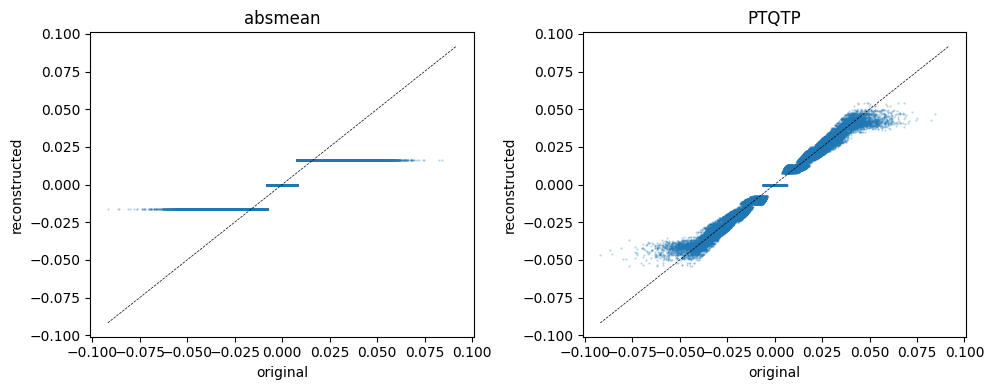

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, recon, label in [
    (axes[0], W_abs, "absmean"),
    (axes[1], W_ptq, "PTQTP"),
]:
    ax.scatter(W.flatten().numpy(), recon.flatten().detach().numpy(), s=0.3, alpha=0.3)
    lim = W.abs().max().item()
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
    ax.set_xlabel("original")
    ax.set_ylabel("reconstructed")
    ax.set_title(label)

plt.tight_layout()
plt.show()

## Trit-plane statistics

T1 captures the coarse sign structure. T2 has more zeros (noise filtering).

In [4]:
for name, t in [("T1", t1), ("T2", t2)]:
    vals, counts = t.unique(return_counts=True)
    total = t.numel()
    dist = {v.item(): f"{c.item() / total:.1%}" for v, c in zip(vals, counts, strict=True)}
    print(f"{name}: {dist}")

T1: {-1: '23.8%', 0: '52.5%', 1: '23.7%'}
T2: {-1: '32.4%', 0: '34.7%', 1: '32.9%'}


for name, t in [("T1", t1), ("T2", t2)]:
    vals, counts = t.unique(return_counts=True)
    total = t.numel()
    dist = {v.item(): f"{c.item() / total:.1%}" for v, c in zip(vals, counts, strict=True)}
    print(f"{name}: {dist}")

In [5]:
from smelt.ptqtp import DualTernaryLinear

torch.manual_seed(0)
linear = nn.Linear(256, 128, bias=False)
x = torch.randn(8, 256)

y_ref = linear(x)
y_ptq = DualTernaryLinear(linear)(x)

nmse = ((y_ref - y_ptq) ** 2).mean() / (y_ref**2).mean()
print(f"single layer NMSE: {nmse:.4f}")

single layer NMSE: 0.0115


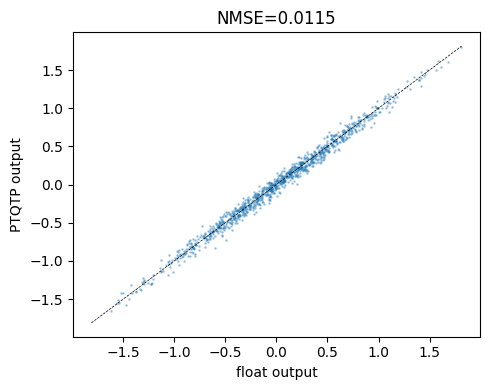

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(
    y_ref.detach().flatten().numpy(),
    y_ptq.detach().flatten().numpy(),
    s=1,
    alpha=0.3,
)
lim = max(y_ref.abs().max().item(), y_ptq.abs().max().item())
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.set_xlabel("float output")
ax.set_ylabel("PTQTP output")
ax.set_title(f"NMSE={nmse:.4f}")
plt.tight_layout()
plt.show()

## smelt.quantize on a float model

smelt auto-detects: already-ternary weights get TernaryLinear (single plane),
float weights get DualTernaryLinear (PTQTP, two planes).

In [7]:
from transformers import LlamaConfig, LlamaForCausalLM

import smelt

torch.manual_seed(0)
model = LlamaForCausalLM(
    LlamaConfig(
        hidden_size=128,
        num_hidden_layers=2,
        num_attention_heads=4,
        intermediate_size=256,
        vocab_size=1000,
    )
)

ids = torch.randint(0, 1000, (1, 16))
with torch.no_grad():
    ref = model(ids).logits

smelt.quantize(model)

with torch.no_grad():
    ptq = model(ids).logits

cos = torch.nn.functional.cosine_similarity(ref.flatten(), ptq.flatten(), dim=0)
print(f"logits cosine similarity: {cos:.4f}")
print(f"argmax match: {(ref.argmax(-1) == ptq.argmax(-1)).float().mean():.1%}")

logits cosine similarity: 0.9363
argmax match: 56.2%
